## 1. Instalação das dependências

In [2]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.4 MB/s eta 0:00:00


## 2. Imports

In [3]:
import time
import torch
from ultralytics import YOLO
from PIL import Image
from IPython.display import display, HTML
import urllib.request
import matplotlib.pyplot as plt
import os

print("✅ Imports carregados!")
print(f"GPU disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports carregados!
GPU disponível: True
GPU: Tesla T4


## 3. Carregar imagem de teste

⚠️ **IMPORTANTE:** Troque a URL abaixo pela imagem que você escolher!

**Dicas para escolher uma boa imagem:**
- Rua movimentada com pessoas, veículos, etc.
- Mercados, feiras, parques com bastante gente
- Quanto mais variedade de objetos, melhor a comparação

O COCO Dataset reconhece 80 classes: person, bicycle, car, motorcycle, bus, truck, dog, cat, chair, backpack, etc.

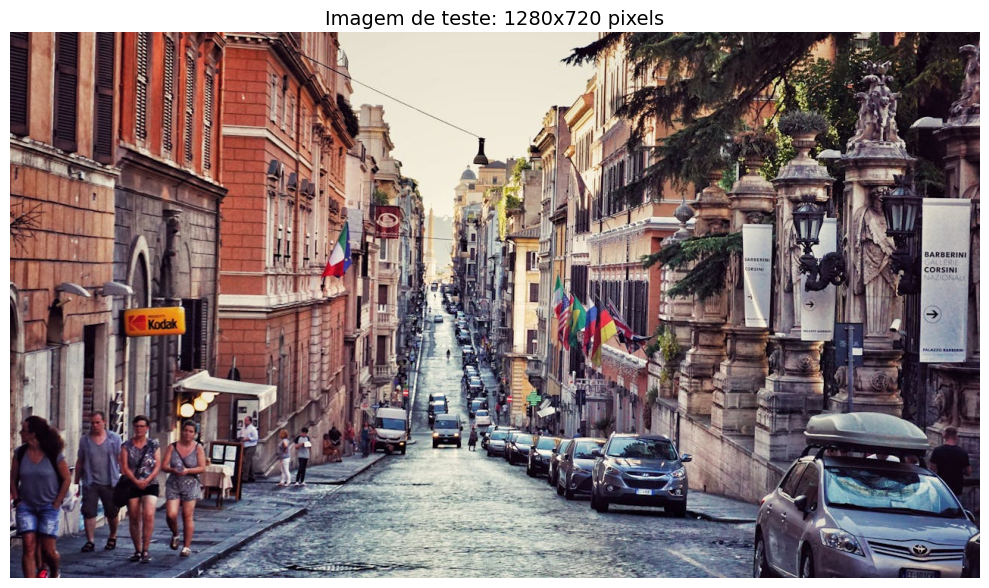

In [12]:
import requests

url = "https://images.pexels.com/photos/6420697/pexels-photo-6420697.jpeg?auto=compress&w=1280"

headers = {"User-Agent": "Mozilla/5.0"}
r = requests.get(url, headers=headers)
with open("imagem_teste.jpg", "wb") as f:
    f.write(r.content)

img = Image.open("imagem_teste.jpg")
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(img)
ax.set_title(f"Imagem de teste: {img.size[0]}x{img.size[1]} pixels", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Executar todas as versões do YOLO

Esta célula roda as 5 versões (n, s, m, l, x) e coleta:
- Tempo de inferência (ms)
- Objetos detectados por classe
- Total de detecções

In [13]:
versoes = ['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x']
resultados = {}

for versao in versoes:
    print(f'\n{"="*50}')
    print(f'🔄 Rodando {versao.upper()}...')
    print(f'{"="*50}')

    # Carregar modelo
    modelo = YOLO(f'{versao}.pt')

    # Rodar inferência
    resultado = modelo('imagem_teste.jpg')

    # Extrair informações
    r = resultado[0]
    tempo_ms = r.speed['inference']

    # Contar objetos por classe
    objetos = {}
    for cls_id in r.boxes.cls:
        nome_classe = r.names[int(cls_id)]
        objetos[nome_classe] = objetos.get(nome_classe, 0) + 1

    resultados[versao] = {
        'tempo_ms': round(tempo_ms, 1),
        'objetos': objetos,
        'total': len(r.boxes)
    }

    print(f'Tempo: {tempo_ms:.1f} ms')
    print(f'Objetos detectados ({len(r.boxes)} total): {objetos}')

print('\n\n Todos os testes concluídos!')


🔄 Rodando YOLO11N...

image 1/1 /content/imagem_teste.jpg: 384x640 8 persons, 10 cars, 1 truck, 1 traffic light, 87.1ms
Speed: 10.8ms preprocess, 87.1ms inference, 49.2ms postprocess per image at shape (1, 3, 384, 640)
⏱️  Tempo: 87.1 ms
📦 Objetos detectados (20 total): {'car': 10, 'person': 8, 'traffic light': 1, 'truck': 1}

🔄 Rodando YOLO11S...

image 1/1 /content/imagem_teste.jpg: 384x640 10 persons, 9 cars, 1 truck, 1 traffic light, 63.8ms
Speed: 2.0ms preprocess, 63.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
⏱️  Tempo: 63.8 ms
📦 Objetos detectados (21 total): {'person': 10, 'car': 9, 'truck': 1, 'traffic light': 1}

🔄 Rodando YOLO11M...

image 1/1 /content/imagem_teste.jpg: 384x640 8 persons, 8 cars, 1 truck, 50.7ms
Speed: 2.2ms preprocess, 50.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
⏱️  Tempo: 50.7 ms
📦 Objetos detectados (17 total): {'person': 8, 'car': 8, 'truck': 1}

🔄 Rodando YOLO11L...

image 1/1 /content/imagem_teste.j

## 5. Visualizar resultados de cada versão


image 1/1 /content/imagem_teste.jpg: 384x640 8 persons, 10 cars, 1 truck, 1 traffic light, 8.3ms
Speed: 1.6ms preprocess, 8.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/imagem_teste.jpg: 384x640 10 persons, 9 cars, 1 truck, 1 traffic light, 11.5ms
Speed: 1.5ms preprocess, 11.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/imagem_teste.jpg: 384x640 8 persons, 8 cars, 1 truck, 24.8ms
Speed: 1.6ms preprocess, 24.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/imagem_teste.jpg: 384x640 8 persons, 8 cars, 1 truck, 31.5ms
Speed: 1.6ms preprocess, 31.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/imagem_teste.jpg: 384x640 9 persons, 12 cars, 1 truck, 57.2ms
Speed: 1.5ms preprocess, 57.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


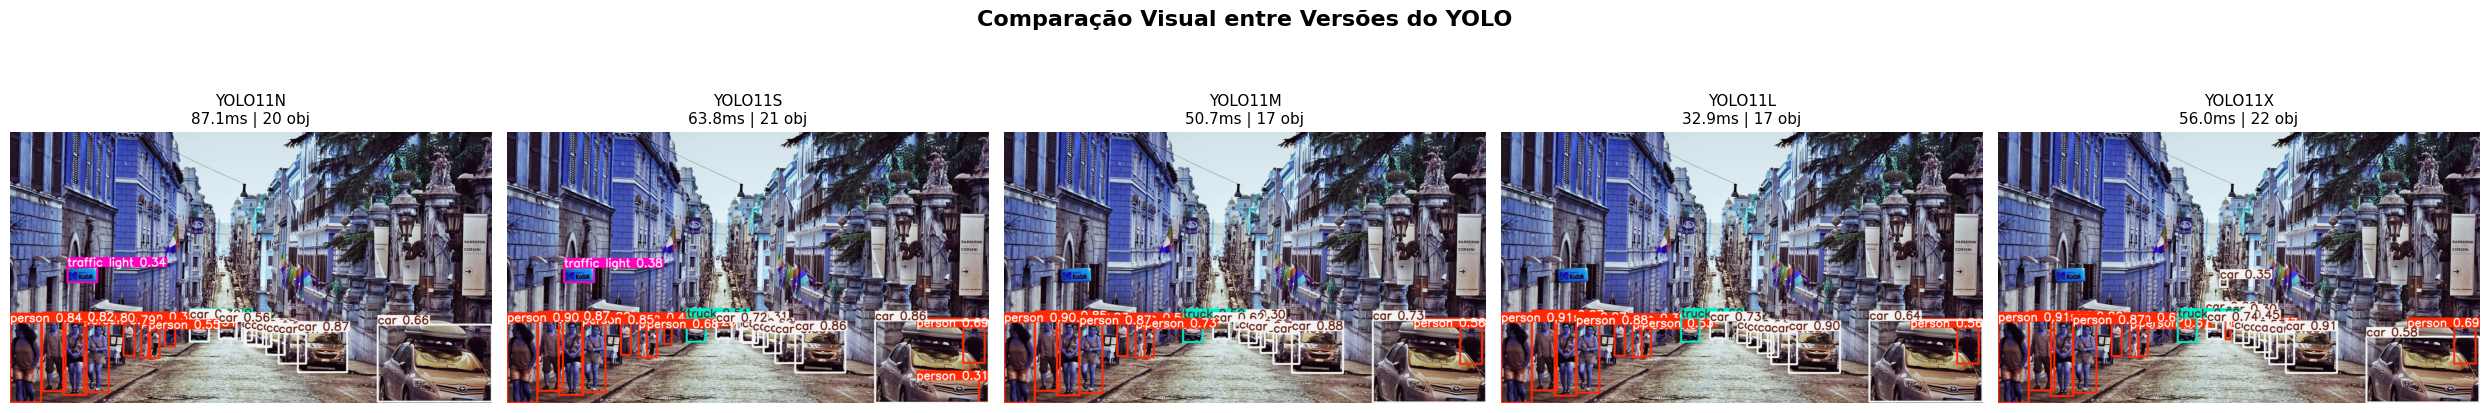


📁 Imagens individuais salvas como resultado_yolo11n.jpg, resultado_yolo11s.jpg, etc.
   Acesse pelo ícone de pasta à esquerda para baixar.


In [14]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, versao in enumerate(versoes):
    modelo = YOLO(f'{versao}.pt')
    resultado = modelo('imagem_teste.jpg')
    r = resultado[0]
    img_anotada = r.plot()

    # Salvar imagem individual
    nome_arquivo = f'resultado_{versao}.jpg'
    Image.fromarray(img_anotada).save(nome_arquivo)

    axes[i].imshow(img_anotada)
    axes[i].set_title(f"{versao.upper()}\n{resultados[versao]['tempo_ms']}ms | {resultados[versao]['total']} obj", fontsize=11)
    axes[i].axis('off')

plt.suptitle('Comparação Visual entre Versões do YOLO', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Imagens individuais salvas como resultado_yolo11n.jpg, resultado_yolo11s.jpg, etc.')
print('   Acesse pelo ícone de pasta à esquerda para baixar.')

## 6. Tabela resumo dos resultados

In [15]:
# Coletar todas as classes detectadas
todas_classes = set()
for v in resultados.values():
    todas_classes.update(v['objetos'].keys())
todas_classes = sorted(todas_classes)

# Traduzir classes comuns do COCO para português
traducao = {
    'person': 'Pessoa', 'bicycle': 'Bicicleta', 'car': 'Carro',
    'motorcycle': 'Moto', 'bus': 'Ônibus', 'truck': 'Caminhão',
    'traffic light': 'Semáforo', 'stop sign': 'Placa de Pare',
    'backpack': 'Mochila', 'umbrella': 'Guarda-chuva',
    'handbag': 'Bolsa', 'suitcase': 'Mala', 'chair': 'Cadeira',
    'bench': 'Banco', 'dog': 'Cachorro', 'cat': 'Gato',
    'horse': 'Cavalo', 'potted plant': 'Planta', 'dining table': 'Mesa',
    'cell phone': 'Celular', 'book': 'Livro', 'clock': 'Relógio',
    'bottle': 'Garrafa', 'cup': 'Copo', 'tv': 'TV',
    'laptop': 'Notebook', 'skateboard': 'Skate', 'bird': 'Pássaro',
}

# Gerar tabela HTML
html = '<h3>📊 Tabela de Resultados</h3>'
html += '<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; text-align: center;">'

# Cabeçalho
html += '<tr style="background-color: #2c3e50; color: white;">'
html += '<th>Versão YOLO</th><th>Tempo (ms)</th><th>Total</th>'
for cls in todas_classes:
    nome_pt = traducao.get(cls, cls.title())
    html += f'<th>{nome_pt}</th>'
html += '</tr>'

# Dados
cores = ['#ecf0f1', '#ffffff']
for i, versao in enumerate(versoes):
    r = resultados[versao]
    cor = cores[i % 2]
    sufixo = versao.replace('yolo11', '')
    html += f'<tr style="background-color: {cor};">'
    html += f'<td><b>YOLO11{sufixo}</b></td>'
    html += f'<td>{r["tempo_ms"]}</td>'
    html += f'<td><b>{r["total"]}</b></td>'
    for cls in todas_classes:
        qtd = r['objetos'].get(cls, 0)
        html += f'<td>{qtd if qtd > 0 else "-"}</td>'
    html += '</tr>'

html += '</table>'
display(HTML(html))

# Também em texto puro
print('\n\n📋 VERSÃO TEXTO (para copiar):\n')
header = f'{"Versão":<12} {"Tempo (ms)":<12} {"Total":<8}'
for cls in todas_classes:
    nome_pt = traducao.get(cls, cls.title())
    header += f' {nome_pt:<14}'
print(header)
print('-' * len(header))

for versao in versoes:
    r = resultados[versao]
    sufixo = versao.replace('yolo11', '')
    linha = f'YOLO11{sufixo:<6} {r["tempo_ms"]:<12} {r["total"]:<8}'
    for cls in todas_classes:
        qtd = r['objetos'].get(cls, 0)
        linha += f' {qtd if qtd > 0 else "-":<14}'
    print(linha)

Versão YOLO,Tempo (ms),Total,Carro,Pessoa,Semáforo,Caminhão
YOLO11n,87.1,20,10,8,1,1
YOLO11s,63.8,21,9,10,1,1
YOLO11m,50.7,17,8,8,-,1
YOLO11l,32.9,17,8,8,-,1
YOLO11x,56.0,22,12,9,-,1




📋 VERSÃO TEXTO (para copiar):

Versão       Tempo (ms)   Total    Carro          Pessoa         Semáforo       Caminhão      
----------------------------------------------------------------------------------------------
YOLO11n      87.1         20       10             8              1              1             
YOLO11s      63.8         21       9              10             1              1             
YOLO11m      50.7         17       8              8              -              1             
YOLO11l      32.9         17       8              8              -              1             
YOLO11x      56.0         22       12             9              -              1             


## 7. Próximos passos

1. **Baixe as imagens**: clique no ícone de pasta à esquerda e baixe os arquivos `resultado_yolo11*.jpg`
2. **Copie a tabela** de resultados acima
3. **Envie os resultados** para o Claude montar o conteúdo do seu trabalho

### O que enviar:
- A tabela com tempos e objetos detectados
- Qual imagem você usou (descrição ou link)
- Observações interessantes que você notou nas detecções